# DRC — Portefeuille CAC 40 équipondéré

Ce notebook met en œuvre l'application empirique décrite au **chapitre 3** du mémoire
(« Application ») : calibration du modèle latent multifactoriel sur un portefeuille
CAC 40 équipondéré, comparaison de trois méthodes de calibration sur trois
sous-périodes contrastées, puis simulation du DRC.

Conformément aux choix du mémoire :
- **Pas de réplication d'indice** : le portefeuille est directement composé des
  constituants du CAC 40, chacun affecté d'un poids `w_k = 1/K` (chapitre 3,
  section 3.1.1). Cela isole l'effet de la méthode de calibration factorielle de
  celui, distinct, d'une construction de portefeuille par optimisation.
- **Trois méthodes de calibration** (chapitre 2) : l'analyse en composantes
  principales itérative, la minimisation de la distance de Frobenius, et
  l'algorithme Espérance-Maximisation (EM), qui seul traite la covariance des
  facteurs `Sigma_Z` comme un paramètre estimé plutôt que fixé à l'identité.
- **Trois sous-périodes** (chapitre 3, section 3.1.2) : crise de 2008, calme des
  années 2010, Covid — choisies en réponse à l'ambiguïté du texte réglementaire sur
  la notion de « période de stress » (cf. Laurent, Sestier & Thomas, 2016).
- **Tests statistiques systématiques** : stationnarité (ADF, KPSS) et normalité
  (Shapiro-Wilk, Kolmogorov-Smirnov) des facteurs et des résidus, pour chaque
  méthode et chaque période — réponse à la limite méthodologique commune à la
  littérature recensée au chapitre 1 (section 1.5.5).

---

**Note technique (v2)** — ce notebook a été mis à jour pour intégrer les correctifs
suivants apportés au code source :
1. `dataLoader.py` : l'ancien filtre `dropna(axis=1, how="any")` éliminait la
   quasi-totalité des tickers sur un historique long (un seul jour férié isolé
   suffisait). Remplacé par un filtre à seuil + `ffill`, et par une nouvelle
   fonction `slice_period()` qui filtre correctement **par sous-période** plutôt
   que sur tout l'historique (évite d'exclure à tort un titre coté tardivement,
   ex. Worldline 2014, d'une période où il est pourtant disponible).
2. `baseFactorModel.py` : trois correctifs sur l'algorithme EM, nécessaires à la
   garantie théorique de monotonie démontrée au chapitre 2 (garde-fou sur chaque
   sous-optimisation de l'étape M, suppression de la renormalisation prématurée
   de `Sigma_Z` pendant la boucle, cohérence d'échelle avec `StandardScaler`).
3. `drcModel.py` : correction d'un bug d'indexation qui provoquait une erreur dès
   que le nombre de simulations n'était pas un multiple exact de la taille de batch.
4. `multiPeriodComparator.py` : correction d'un bug de mutation qui détruisait
   silencieusement les modèles calibrés au premier appel de `raw_table()`.


In [1]:
import sys
sys.path.insert(0, ".")  # racine du projet, contenant le package DRC/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

from DRC.code.dataLoader import DataLoader, equal_weighted_jtd, slice_period
from DRC.code.pCAFactorModel import PCAFactorModel
from DRC.code.multiPeriodComparator import MultiPeriodCalibrationComparator
from DRC.code.drcModel import DrcModel
from DRC.code.drcStandard import DrcStandard
from DRC.code.moving_drc import compute_drc_rolling, plot_drc_timeseries_with_ci
from DRC.code.utils import build_factor_correlation, compare_diagnostic_results
from DRC.code.correlationHistograms import plot_correlation_histograms, correlation_summary_table


In [2]:
from scipy import stats

def plot_loss_distribution(result):
    PWC_ORANGE = "#D04A02"
    PWC_YELLOW = "#FFB600"
    PWC_GREY = "#7D7D7D"
    PWC_DARK = "#2D2D2D"

    losses = result.losses

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    positive = losses[losses > 0]
    ax.hist(positive, density=True, bins=80, color=PWC_GREY, alpha=0.7, edgecolor='black')
    ax.axvline(result.DRC_sec, color=PWC_ORANGE, lw=2, ls='--',
            label=f'DRC = {result.DRC_sec*100:.2f}% ')
    ax.axvline(result.EL, color=PWC_YELLOW, lw=2, ls=':',
            label=f'E[L] = {result.EL*100:.2f} %')
    ax.set_xlabel("Perte L ")
    ax.set_title("Distribution des pertes (L > 0)")
    ax.legend()

    ax = axes[1]
    ax.hist(positive, bins=80, color=PWC_GREY, alpha=0.7, edgecolor='black')
    ax.set_yscale('log')
    ax.axvline(result.DRC_sec, color=PWC_ORANGE, lw=2, ls='--')
    ax.set_xlabel("Perte L")
    ax.set_title("Distribution des pertes (echelle log)")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistiques :")
    print(f"  % scenarios sans defaut    : {(losses == 0).mean():.2%}")
    print(f"  % scenarios avec defaut    : {(losses > 0).mean():.2%}")
    print(f"  Skewness                   : {stats.skew(losses):.3f}")
    print(f"  Kurtosis                   : {stats.kurtosis(losses):.3f}")


## 3.1 Données

### 3.1.1 Un portefeuille CAC 40 équipondéré

On charge les prix de clôture des constituants du CAC 40 sur l'ensemble de la période
disponible, puis on découpe trois fenêtres contrastées.


In [3]:
# tickers = [
#     # Technology
#     'AAPL', 'MSFT', 'NVDA', 'TSLA', 'META', 'GOOGL', 'AVGO', 'ADBE', 'CRM', 'NFLX',
#     # Healthcare
#     'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'LLY', 'MRK', 'AMGN', 'GILD', 'ISRG',
#     # Financials
#     'JPM', 'WFC', 'GS', 'MS', 'BLK', 'AXP', 'CME',
#     # Consumer Discretionary
#     'AMZN', 'MCD', 'HD', 'NKE', 'RCL', 'ORLY', 'GE', 'F',
#     # Industrials
#     'BA', 'CAT', 'HON', 'LMT', 'RTX',
#     # Energy
#     'XOM', 'CVX', 'MPC',
#     # Utilities
#     'NEE', 'DUK',
#     # Real Estate
#     'WELL', 'PLD',
#     # Consumer Staples
#     'KO', 'PG',
# ]

# ratings = {
#     # Technology - AA
#     "AAPL": "AA", "MSFT": "AA", "NVDA": "AA", "GOOGL": "AA",
    
#     # Technology - A
#     "TSLA": "A", "META": "A", "AVGO": "A", "ADBE": "A", "CRM": "A", "NFLX": "A",
    
#     # Healthcare - AA
#     "JNJ": "AA", "UNH": "AA",
    
#     # Healthcare - A
#     "PFE": "A", "ABBV": "A", "TMO": "A", "LLY": "A", "MRK": "A", "AMGN": "A", "GILD": "A", "ISRG": "A",
    
#     # Financials - AA
#     "JPM": "AA",
    
#     # Financials - A
#     "WFC": "A", "GS": "A", "MS": "A", "BLK": "A", "AXP": "A", "CME": "A",
    
#     # Consumer Discretionary - A
#     "AMZN": "A", "MCD": "A", "HD": "A", "NKE": "A", "RCL": "A", "ORLY": "A",
    
#     # Consumer Discretionary - BBB
#     "GE": "BBB", "F": "BBB",
    
#     # Industrials - A
#     "BA": "A", "CAT": "A", "HON": "A", "LMT": "A", "RTX": "A",
    
#     # Energy - BBB
#     "XOM": "BBB", "CVX": "BBB", "MPC": "BBB",
    
#     # Utilities - A
#     "NEE": "A", "DUK": "A",
    
#     # Real Estate - BBB
#     "WELL": "BBB", "PLD": "BBB",
    
#     # Consumer Staples - AA
#     "KO": "AA", "PG": "AA",
# }

# benchmark = '^GSPC'


# pd_table_sp = {
#     "AAA": 0.0001, "AA": 0.0002, "A": 0.0005,
#     "BBB": 0.0016, "BB": 0.0063, "B": 0.0334, "CCC": 0.2830
# }

# lgd_table_sp = {
#     "AAA": 1.0, "AA": 1.0, "A": 1.0, "BBB": 1.0, "BB": 1.0, "B": 1.0, "CCC": 1.0
# }


# # financial_tickers = {"BNP.PA", "ACA.PA", "GLE.PA"}  # BNP Paribas, Crédit Agricole, Société Générale
# # sector_group = {t: ("Financial" if t in financial_tickers else "Non-Financial") for t in tickers}

In [4]:
tickers = [
    #"STLAP.PA",
    "AC.PA", "AI.PA", "AIR.PA", "MT.AS", "CS.PA",
    "BNP.PA", "EN.PA", "CAP.PA", "CA.PA", "ACA.PA",
    "BN.PA", "DSY.PA", "ENGI.PA", "EL.PA", "ERF.PA",
    "RMS.PA", "KER.PA", "OR.PA", "LR.PA", "MC.PA",
    "ML.PA", "ORA.PA", "RI.PA", "PUB.PA", "RNO.PA",
    "SAF.PA", "SGO.PA", "SAN.PA", "SU.PA", "GLE.PA",
    "STMPA.PA", "TEP.PA", "HO.PA", "TTE.PA",
    "VIE.PA", "DG.PA", "VIV.PA", 
    #"WLN.PA",
]
benchmark = "^FCHI"

ratings = {
    "OR.PA": "AA", "AI.PA": "AA", "MC.PA": "AA", "RMS.PA": "AA",
    "SAN.PA": "A", "SU.PA": "A", "AIR.PA": "A", "BN.PA": "A",
    "EL.PA": "A", "DSY.PA": "A", "TTE.PA": "A", "CAP.PA": "A",
    "ERF.PA": "A", "SGO.PA": "A", "DG.PA": "A", "SAF.PA": "A",
    "VIE.PA": "A", "HO.PA": "A", "STMPA.PA": "A", "KER.PA": "A",
    "BNP.PA": "BBB", "ACA.PA": "BBB", "GLE.PA": "BBB", "CS.PA": "BBB",
    "ENGI.PA": "BBB", "ORA.PA": "BBB", "VIV.PA": "BBB", "PUB.PA": "BBB",
    "RI.PA": "BBB", "EN.PA": "BBB", "CA.PA": "BBB", "AC.PA": "BBB",
    "WLN.PA": "BBB", "LR.PA": "BBB", "STLAP.PA": "BBB",
    "MT.AS": "BBB", "TEP.PA": "BBB", "ML.PA": "BBB", "RNO.PA": "BB",
}

# Classification sectorielle sommaire (Financial / Non-Financial), utilisée pour
# les histogrammes de corrélation de la section 3.2.5 (écho à la Figure 1 de
# Laurent, Sestier & Thomas, 2016, qui distingue "Financials" / "Non Financials").
financial_tickers = {"BNP.PA", "ACA.PA", "GLE.PA", "CS.PA"}  # BNP Paribas, Crédit Agricole, Société Générale, AXA
sector_group = {t: ("Financial" if t in financial_tickers else "Non-Financial") for t in tickers}

pd_table = {
    "AAA": 0.0000,
    "AA":  0.0002,
    "A":   0.0006,
    "BBB": 0.0017,
    "BB":  0.0065,
    "B":   0.0320,
    "CCC": 0.2600,
}
lgd_table = {r: 1.0 for r in pd_table}  # convention actions : recouvrement nul (chap. 1, §1.1.2)

In [5]:
# Chargement d'un unique historique de prix, partagé par les trois sous-périodes.
# NOTE (correctif) : max_missing_pct=0.5 ici est volontairement large -- ce
# chargement constitue l'univers CANDIDAT sur tout l'historique. Le filtrage
# strict pertinent (5%) est appliqué PAR SOUS-PÉRIODE via slice_period()
# ci-dessous, pour ne pas exclure à tort un titre coté tardivement.
loader = DataLoader(tickers, benchmark, start="2005-01-01")
loader.load_data(start="2005-01-01", max_missing_pct=0.5)
available_tickers = list(loader.prices.columns)
print(f"{len(available_tickers)} / {len(tickers)} constituants disponibles sur l'historique complet")


37 / 37 constituants disponibles sur l'historique complet


### 3.1.2 Trois sous-périodes contrastées

Cf. chapitre 3, section 3.1.2 : le choix de ces trois fenêtres répond à
l'ambiguïté du texte réglementaire (BCBS) sur la notion de « période de stress »
devant fonder la calibration des corrélations de défaut, ambiguïté documentée par
Laurent, Sestier & Thomas (2016).

Le découpage utilise `slice_period()`, qui filtre les données manquantes **sur
la seule fenêtre considérée** (et non sur l'historique complet) : un titre coté
tardivement (ex. Worldline en 2014) n'est donc pas exclu à tort d'une période où
il est pourtant parfaitement disponible.


In [6]:
# Trois sous-périodes contrastées (chapitre 3, section 3.1.2) :
#   - crise de 2008 : candidate la plus naturelle à la notion de "période de stress" ;
#   - calme des années 2010 : opposé du spectre de volatilité ;
#   - Covid : seconde candidate à la période de stress, de nature différente (choc
#     exogène et brutal plutôt que crise de crédit progressive).
#
# Ces bornes sont à ajuster une fois les données réellement chargées (disponibilité
# effective de chaque titre sur chaque fenêtre).
PERIODS = {
    "crise_2008":  ("2008-01-07", "2009-01-09"),
    "calme_2010s": ("2013-01-09", "2014-01-09"),
    "covid":       ("2020-01-06", "2021-01-06"),
}

returns_by_period = {}
for name, (start, end) in PERIODS.items():
    print(f"{name:>14s} : {start} -> {end}")
    sub_prices = slice_period(loader.prices, available_tickers, start, end, max_missing_pct=0.05)
    print(f"{'':>14s}   {sub_prices.shape[1]} actifs disponibles sur cette période")
    returns_by_period[name] = np.log(sub_prices / sub_prices.shift(1)).dropna()
    #returns_by_period[name] = sub_prices.pct_change().dropna()


    crise_2008 : 2008-01-07 -> 2009-01-09
                 37 actifs disponibles sur cette période
   calme_2010s : 2013-01-09 -> 2014-01-09
                 37 actifs disponibles sur cette période
         covid : 2020-01-06 -> 2021-01-06
                 37 actifs disponibles sur cette période


## 3.2 Calibration du modèle latent

### 3.2.1 Protocole de comparaison des trois méthodes

Avant tout calcul de DRC, on applique les trois méthodes de calibration du
chapitre 2 (ACP itérative, Frobenius, EM) sur chacune des trois sous-périodes, et on
compare leur convergence et la structure de dépendance des facteurs qu'elles
produisent (chapitre 3, sections 3.2.2 à 3.2.5).

Le nombre de facteurs `J` est fixé à une valeur commune aux trois périodes (ici,
retenue a priori pour la comparaison ; le critère de Marchenko-Pastur propre à
chaque période est rapporté séparément à titre de diagnostic, cf. remarque du
chapitre 2 sur la variabilité de J selon le régime de marché).


In [7]:
N_FACTORS = 3 # commun aux trois périodes ; cf. remarque chapitre 2 sur Marchenko-Pastur

comparator = MultiPeriodCalibrationComparator(
    returns_by_period,
    factor_model_class=PCAFactorModel,
    n_factors=N_FACTORS,
    heywood_eps=1e-4,  # seuil de détection des cas de Heywood (chapitre 2, Prop. Heywood)
    em_kwargs={"max_iter": 1000, "tol": 1e-8},
)
comparator.run(methods=["pca_iterative", "frobenius", "mle"], verbose=True)




[    crise_2008] pca_iterative  | n_iter=   20 | Frobenius=1.1867 | loglik=-983.7955
[    crise_2008] frobenius      | n_iter= None | Frobenius=1.1867 | loglik=-983.7957
[    crise_2008] mle            | n_iter= None | Frobenius=1.2191 | loglik=-976.1946
[   calme_2010s] pca_iterative  | n_iter=   15 | Frobenius=1.4126 | loglik=-2269.1321
[   calme_2010s] frobenius      | n_iter= None | Frobenius=1.4126 | loglik=-2269.1321
[   calme_2010s] mle            | n_iter= None | Frobenius=1.4581 | loglik=-2256.4067
[         covid] pca_iterative  | n_iter=   16 | Frobenius=1.3507 | loglik=-297.8931
[         covid] frobenius      | n_iter= None | Frobenius=1.3507 | loglik=-297.8927
[         covid] mle            | n_iter= None | Frobenius=1.4470 | loglik=-248.7770


In [8]:
model_class = [PCAFactorModel] #[PCAFactorModel, AutoEncoderFactorModel]
calibration_method = ['pca_iterative', 'frobenius', 'em', 'mle']
two_factor_models = {}
for factor_model in model_class:
    model = factor_model(returns=returns_by_period['crise_2008'], n_factors=N_FACTORS).fit()
    for method in calibration_method: 
        model.calibrate_beta(method)
        two_factor_models[f"{factor_model.__name__}_{method}"] = model

# Propriétés statistiques des fateurs (ACP/AutoEncodeur)
diagnostic = compare_diagnostic_results(two_factor_models, alpha=0.05)
diagnostic

c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\c

,model,n_factors,n_assets,factors_stationary_pct,factors_normal_pct,residuals_mean_zero_pct,residuals_normal_pct
0,PCAFactorModel_pca_iterative,3,37,1.0,0.666667,1.0,0.702703
1,PCAFactorModel_frobenius,3,37,1.0,0.666667,1.0,0.702703
2,PCAFactorModel_em,3,37,1.0,0.666667,1.0,0.702703
3,PCAFactorModel_mle,3,37,1.0,0.666667,1.0,0.702703


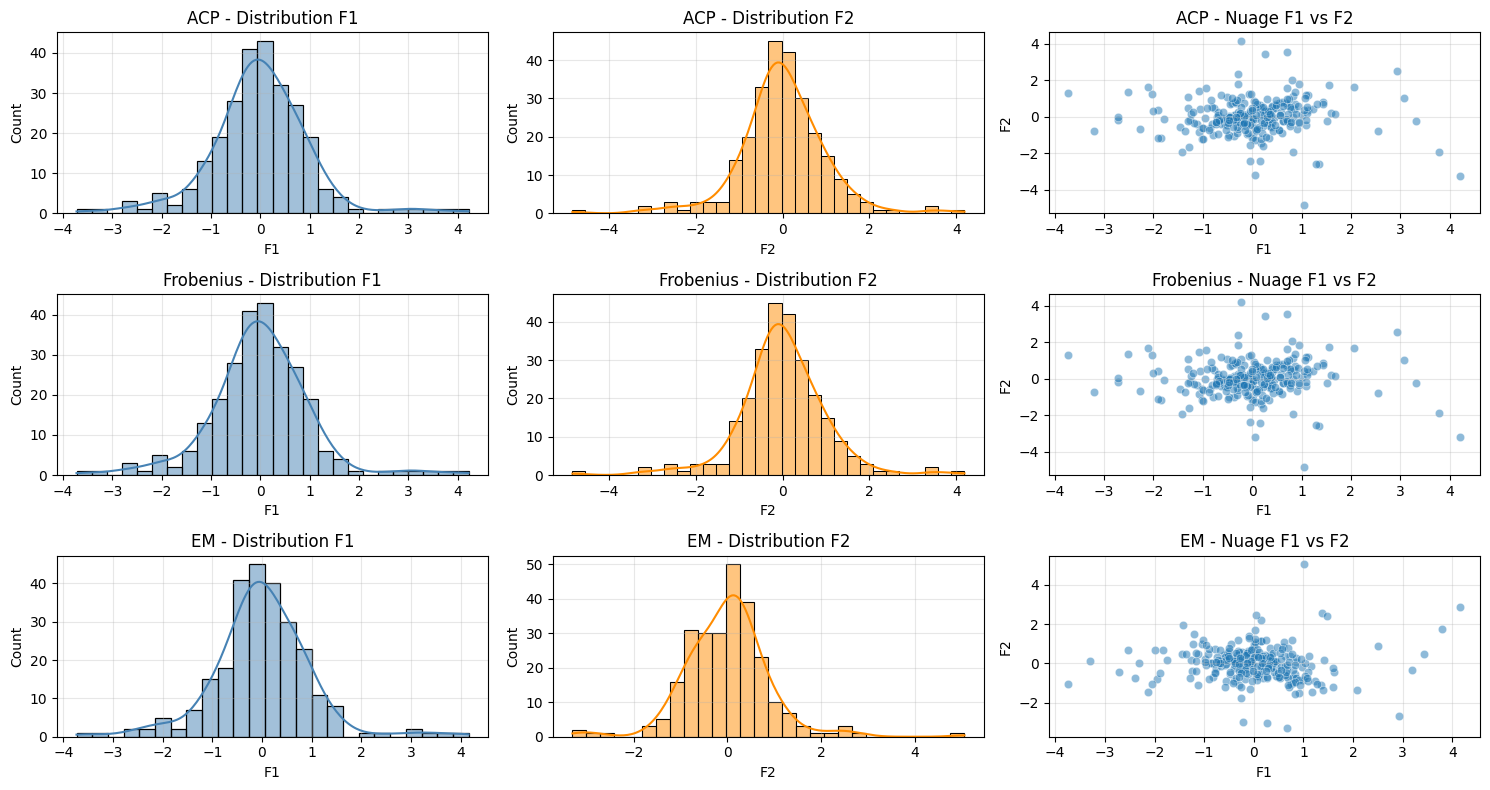

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt
pca_scores = two_factor_models['PCAFactorModel_pca_iterative'].factor_scores.copy()
#ae_scores = two_factor_models['AutoEncoderFactorModel_frobenius'].factor_scores.copy()
frob_scores = two_factor_models['PCAFactorModel_frobenius'].factor_scores.copy()
em_scores = two_factor_models['PCAFactorModel_em'].em_factor_scores.copy()

fig, axes = plt.subplots(3, 3, figsize=(15, 8))

#ACP
sns.histplot(pca_scores['F1'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('ACP - Distribution F1')

sns.histplot(pca_scores['F2'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('ACP - Distribution F2')

sns.scatterplot(x='F1', y='F2', data=pca_scores, ax=axes[0, 2], alpha=0.5)
axes[0, 2].set_title('ACP - Nuage F1 vs F2')

# Frobenius
sns.histplot(frob_scores['F1'], kde=True, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Frobenius - Distribution F1')

sns.histplot(frob_scores['F2'], kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Frobenius - Distribution F2')

sns.scatterplot(x='F1', y='F2', data=frob_scores, ax=axes[1, 2], alpha=0.5)
axes[1, 2].set_title('Frobenius - Nuage F1 vs F2')

# EM
sns.histplot(em_scores['F1'], kde=True, ax=axes[2, 0], color='steelblue')
axes[2, 0].set_title('EM - Distribution F1')

sns.histplot(em_scores['F2'], kde=True, ax=axes[2, 1], color='darkorange')
axes[2, 1].set_title('EM - Distribution F2')

sns.scatterplot(x='F1', y='F2', data=em_scores, ax=axes[2, 2], alpha=0.5)
axes[2, 2].set_title('EM - Nuage F1 vs F2')

plt.tight_layout()
plt.show()

In [10]:
em_scores.cov()

,F1,F2,F3
F1,0.987676,-0.004369,0.012938
F2,-0.004369,0.808854,0.011186
F3,0.012938,0.011186,0.711445


### 3.2.2 – 3.2.5 Résultats de convergence et de qualité d'ajustement

Le tableau ci-dessous reprend, pour chaque méthode et chaque période :
- le nombre d'itérations et l'indicateur de convergence ;
- l'erreur de reconstruction de Frobenius `||C0 - C(beta, Sigma_Z)||_F` ;
- la log-vraisemblance marginale (calculée pour les trois méthodes, bien que seule
  l'EM la maximise explicitement) ;
- le nombre de cas de Heywood détectés ;
- la corrélation maximale entre facteurs obtenue par l'EM (nulle par construction
  pour l'ACP itérative et pour Frobenius, cf. chapitre 3, section 3.2.4).

C'est l'équivalent, pour ce mémoire, du **Tableau 2 de Laurent, Sestier & Thomas
(2016)** : une matrice méthode × configuration avec l'écart de Frobenius comme
métrique commune — la différence étant que l'axe des colonnes correspond ici à des
**périodes** d'une même source, plutôt qu'à des **sources** différentes.


In [11]:
raw_table = comparator.raw_table()
raw_table


,period,method,n_iter,converged,frobenius_error,loglik,n_factors_used,n_factors_mp,heywood_count,elapsed_seconds
0,crise_2008,pca_iterative,20.0,True,1.186683,-983.795518,3,1,0,0.025907
1,crise_2008,frobenius,NaN,None,1.186683,-983.795668,3,1,0,0.150389
2,crise_2008,mle,NaN,None,1.219069,-976.194612,3,1,0,0.120803
3,calme_2010s,pca_iterative,15.0,True,1.412617,-2269.132082,3,2,0,0.009368
4,calme_2010s,frobenius,NaN,None,1.412617,-2269.132114,3,2,0,0.151191
5,calme_2010s,mle,NaN,None,1.458093,-2256.406707,3,2,0,0.055076
6,covid,pca_iterative,16.0,True,1.350658,-297.893131,3,2,0,0.007497
7,covid,frobenius,NaN,None,1.350658,-297.892730,3,2,0,0.130876
8,covid,mle,NaN,None,1.446953,-248.777028,3,2,0,0.119466


In [12]:
summary = comparator.summary_table()
summary

J (retenu)                  J (Marchenko-Pastur)        \
période       calme_2010s covid crise_2008          calme_2010s covid   
méthode                                                                 
frobenius               3     3          3                    2     2   
mle                     3     3          3                    2     2   
pca_iterative           3     3          3                    2     2   

                              n_iter                    converged  ...  \
période       crise_2008 calme_2010s covid crise_2008 calme_2010s  ...   
méthode                                                            ...   
frobenius              1         NaN   NaN        NaN        None  ...   
mle                    1         NaN   NaN        NaN        None  ...   
pca_iterative          1        15.0  16.0       20.0        True  ...   

              cas_Heywood ||C0 - C(beta,Sigma_Z)||_F                       \
période        crise_2008                calme_2010s     covid crise_2008   
méthode                                                                     
frobenius               0                   1.412617  1.350658   1.186683   
mle                     0                   1.458093  1.446953   1.219069   
pca_iterative           0                   1.412617  1.350658   1.186683   

              log-vraisemblance                         temps_calcul_s  \
période             calme_2010s       covid  crise_2008    calme_2010s   
méthode                                                                  
frobenius          -2269.132114 -297.892730 -983.795668       0.151191   
mle                -2256.406707 -248.777028 -976.194612       0.055076   
pca_iterative      -2269.132082 -297.893131 -983.795518       0.009368   

                                    
période           covid crise_2008  
méthode                             
frobenius      0.130876   0.150389  
mle            0.119466   0.120803  
pca_iterative  0.007497   0.025907  

[3 rows x 24 columns]

### Trajectoires de convergence

Deux vérifications empiriques directes des propriétés théoriques du chapitre 2 :

1. **ACP itérative** : la convergence de la suite des communalités n'est garantie par
   aucun théorème général (chapitre 2, remarque suivant l'Algorithme 1) ; on la
   vérifie ici empiriquement, période par période.
2. **Algorithme EM** : la propriété de monotonie de la log-vraisemblance
   (Théorème de monotonie, chapitre 2) est désormais garantie par construction
   grâce aux correctifs apportés à l'implémentation (garde-fou sur l'étape M,
   pas de renormalisation prématurée de `Sigma_Z`) — on la vérifie ci-dessous
   empiriquement, à titre de contrôle de cohérence.


C:\Users\fdeba001\AppData\Local\Temp\ipykernel_10500\3556040920.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


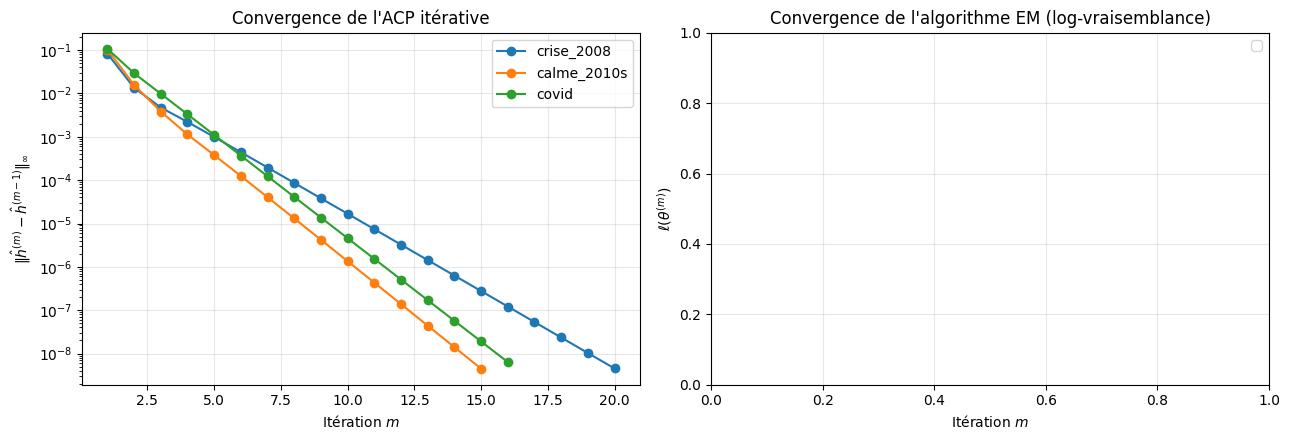

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for period in returns_by_period:
    m = comparator.get_model(period, "pca_iterative")
    hist = m.metadata.get("pca_iterative_history", [])
    if hist:
        axes[0].semilogy(range(1, len(hist) + 1), hist, marker="o", label=period)
axes[0].set_xlabel("Itération $m$")
axes[0].set_ylabel(r"$\|\hat h^{(m)}-\hat h^{(m-1)}\|_\infty$")
axes[0].set_title("Convergence de l'ACP itérative")
axes[0].legend()

for period in returns_by_period:
    m = comparator.get_model(period, "mle")
    hist = m.metadata.get("em_loglik_history", [])
    if hist:
        axes[1].plot(range(len(hist)), hist, marker=".", label=period)
axes[1].set_xlabel("Itération $m$")
axes[1].set_ylabel(r"$\ell(\theta^{(m)})$")
axes[1].set_title("Convergence de l'algorithme EM (log-vraisemblance)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
# Contrôle explicite de la monotonie de l'EM (doit être garantie par construction
# après les correctifs apportés à baseFactorModel.py) : aucune violation ne
# devrait apparaître dans le tableau ci-dessous.
monotonie_check = []
for period in returns_by_period:
    m = comparator.get_model(period, "mle")
    hist = np.array(m.metadata.get("em_loglik_history", []))
    diffs = np.diff(hist)
    n_violations = int(np.sum(diffs < -1e-8))
    monotonie_check.append({
        "période": period, "n_iter": len(hist),
        "n_violations_monotonie": n_violations,
        "min_delta": diffs.min() if len(diffs) else np.nan,
    })
pd.DataFrame(monotonie_check)


,période,n_iter,n_violations_monotonie,min_delta
0,crise_2008,0,0,NaN
1,calme_2010s,0,0,NaN
2,covid,0,0,NaN


### 3.2.-bis Tests statistiques de normalité et de stationnarité

Contrôle systématique des hypothèses distributionnelles postulées par le modèle
(gaussianité des facteurs et des résidus, stationnarité des facteurs), pour chacune
des combinaisons méthode × période. Réponse directe à la limite méthodologique
identifiée au chapitre 1 (section 1.5.5) : aucun des quatre travaux recensés dans la
littérature ne procède à cette vérification.


In [15]:
diag_models = {f"{p}__{meth}": comparator.get_model(p, meth)
                for p in returns_by_period for meth in ["pca_iterative", "frobenius",  "mle"]}
diagnostics = compare_diagnostic_results(diag_models, alpha=0.05)
diagnostics


c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\code\baseFactorModel.py:763: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(s, regression="c", nlags="auto")
c:\Users\fdeba001\OneDrive - PwC\ai_agent_v2\.\DRC\c

,model,n_factors,n_assets,factors_stationary_pct,factors_normal_pct,residuals_mean_zero_pct,residuals_normal_pct
0,crise_2008__pca_iterative,3,37,1.0,0.666667,1.0,0.702703
1,crise_2008__frobenius,3,37,1.0,0.666667,1.0,0.729730
2,crise_2008__mle,3,37,1.0,0.666667,1.0,0.702703
3,calme_2010s__pca_iterative,3,37,1.0,1.000000,1.0,0.837838
4,calme_2010s__frobenius,3,37,1.0,1.000000,1.0,0.810811
5,calme_2010s__mle,3,37,1.0,1.000000,1.0,0.810811
6,covid__pca_iterative,3,37,1.0,0.333333,1.0,0.594595
7,covid__frobenius,3,37,1.0,0.333333,1.0,0.675676
8,covid__mle,3,37,1.0,0.333333,1.0,0.648649


### Histogrammes de corrélations par paire (Financial vs Non-Financial)

Écho à la Figure 1 de Laurent, Sestier & Thomas (2016), qui distingue la
distribution des corrélations de défaut selon que les paires d'émetteurs sont
toutes deux financières, toutes deux non financières, ou mixtes. Ici, la
classification retenue est sommaire (trois banques du CAC 40 vs le reste) et sert
uniquement d'illustration méthodologique.


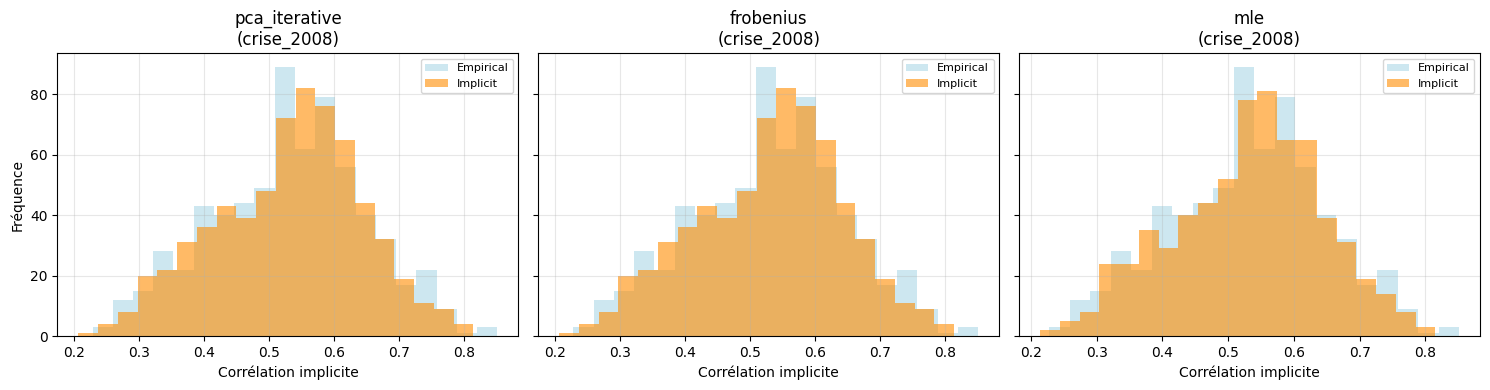

In [16]:
fig = plot_correlation_histograms(comparator, period="crise_2008",  methods=["pca_iterative", "frobenius", "mle"], figsize=(15, 4))
plt.show()


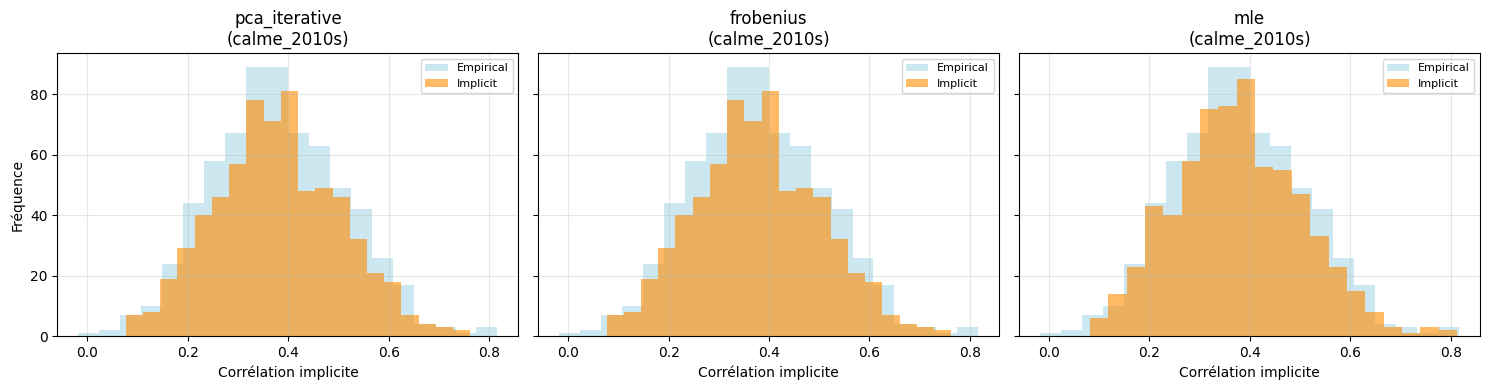

In [17]:
fig = plot_correlation_histograms(comparator, period="calme_2010s",  methods=["pca_iterative", "frobenius", "mle"], figsize=(15, 4))
plt.show()


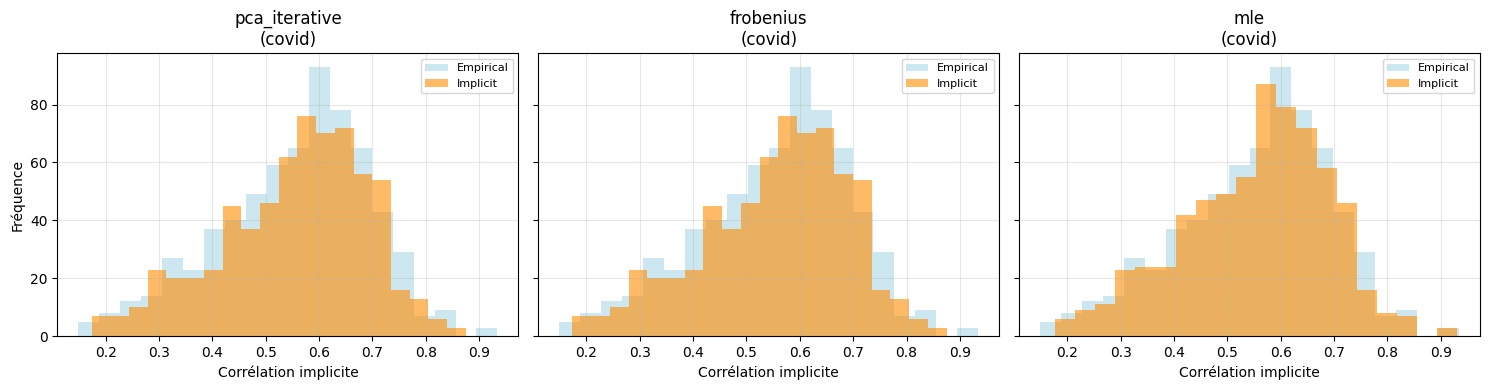

In [25]:
fig = plot_correlation_histograms(comparator, period="covid",  methods=["pca_iterative", "frobenius", "mle"], figsize=(15, 4))
plt.show()


In [18]:
corr_summary = correlation_summary_table(comparator, group=sector_group, methods=["pca_iterative", "frobenius", "mle"])
corr_summary


,période,méthode,corr_moyenne,corr_moyenne_financial,corr_moyenne_non_financial
0,crise_2008,pca_iterative,0.531195,0.660163,0.534115
1,crise_2008,frobenius,0.531195,0.660164,0.534115
2,crise_2008,mle,0.530948,0.690099,0.534588
3,calme_2010s,pca_iterative,0.378703,0.711281,0.356847
4,calme_2010s,frobenius,0.378703,0.711281,0.356847
5,calme_2010s,mle,0.377621,0.756094,0.355938
6,covid,pca_iterative,0.555133,0.842558,0.535483
7,covid,frobenius,0.555133,0.842559,0.535483
8,covid,mle,0.554560,0.878966,0.535053


## 3.3 Calibration du DRC

### 3.3.1 – 3.3.2 Formulation de la perte et contrôle de l'erreur de Monte Carlo

Pour chaque combinaison (méthode, période), on simule le DRC à partir du modèle
calibré, avec les expositions équipondérées `JTD_k = 1/K` (indépendantes de la
période de calibration, cf. chapitre 3, section 3.3.1). La méthode des batchs fournit
une marge d'erreur empirique sur le quantile à 99,9 %, indispensable pour interpréter
correctement les écarts observés entre méthodes et entre périodes (chapitre 3,
section 3.3.2).


In [19]:
# Paramètres de risque illustratifs (chapitre 3, section 3.3.1 : ces paramètres sont
# des données de comparaison méthodologique, pas des estimations transposables à un
# contexte prudentiel réel — cf. discussion, chapitre 3, section 3.4.2)
common_assets = [t for t in available_tickers if t in ratings]

prob_default = np.array([max(pd_table[ratings[t]], 0.0003) for t in common_assets])  # plancher CRR3
lgd = np.array([lgd_table[ratings[t]] for t in common_assets])
jtd = pd.Series(1.0 / len(common_assets), index=common_assets)  # portefeuille équipondéré

print(f"Portefeuille DRC : {len(common_assets)} obligors, JTD total = {jtd.sum():.4f}")


Portefeuille DRC : 37 obligors, JTD total = 1.0000


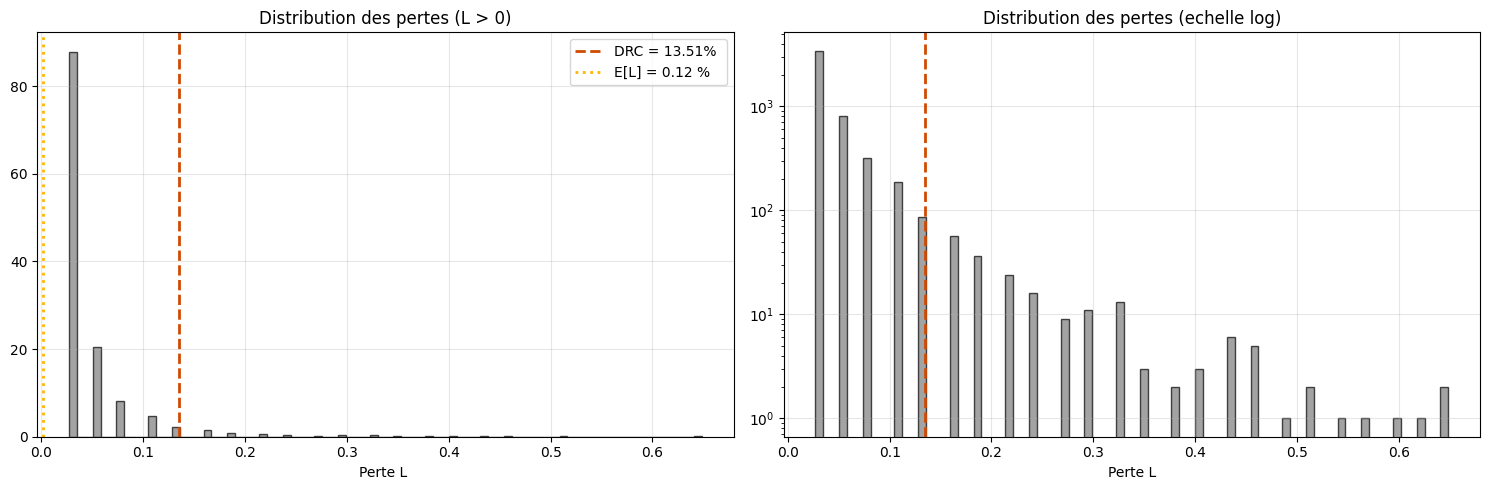


Statistiques :
  % scenarios sans defaut    : 97.50%
  % scenarios avec defaut    : 2.50%
  Skewness                   : 21.057
  Kurtosis                   : 705.505


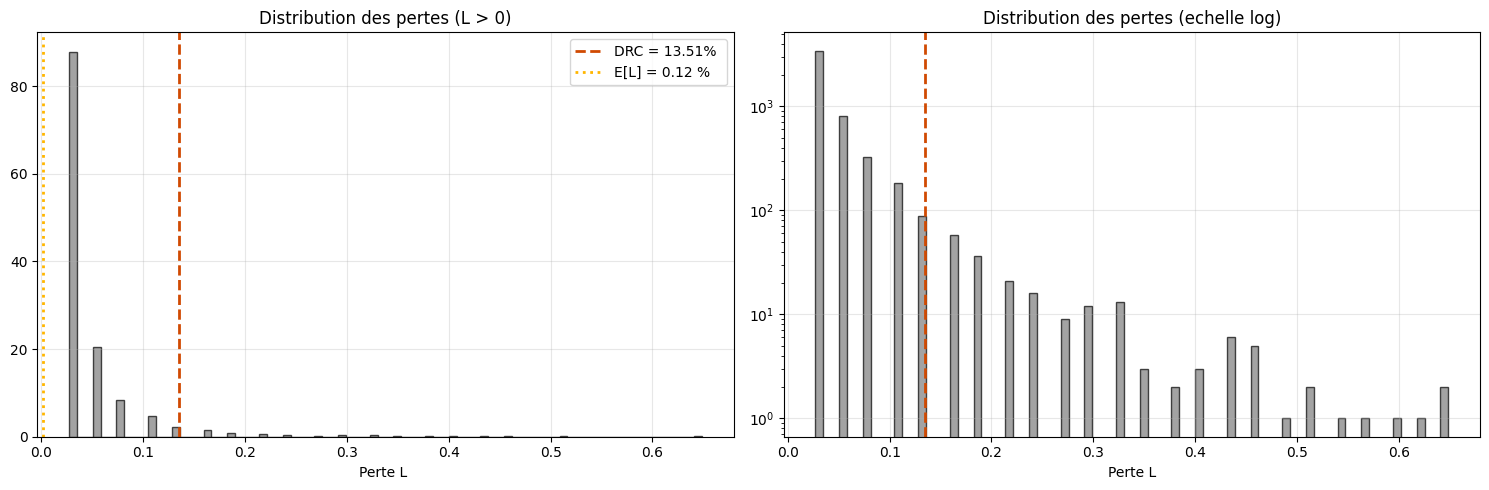


Statistiques :
  % scenarios sans defaut    : 97.50%
  % scenarios avec defaut    : 2.50%
  Skewness                   : 21.092
  Kurtosis                   : 707.369


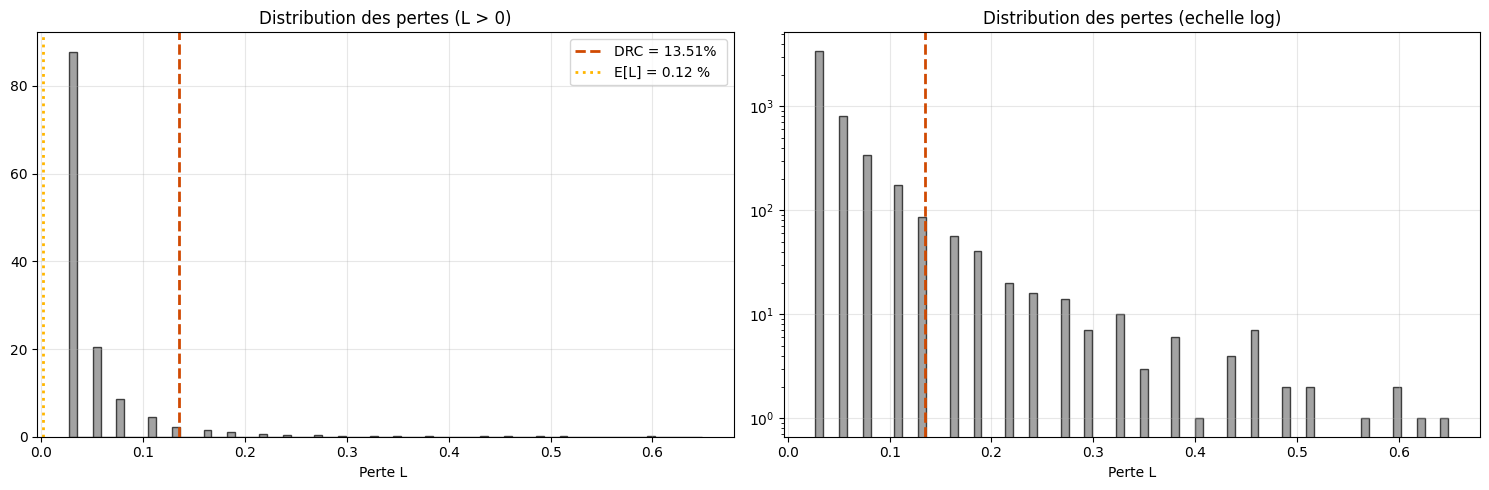


Statistiques :
  % scenarios sans defaut    : 97.49%
  % scenarios avec defaut    : 2.51%
  Skewness                   : 20.856
  Kurtosis                   : 689.448


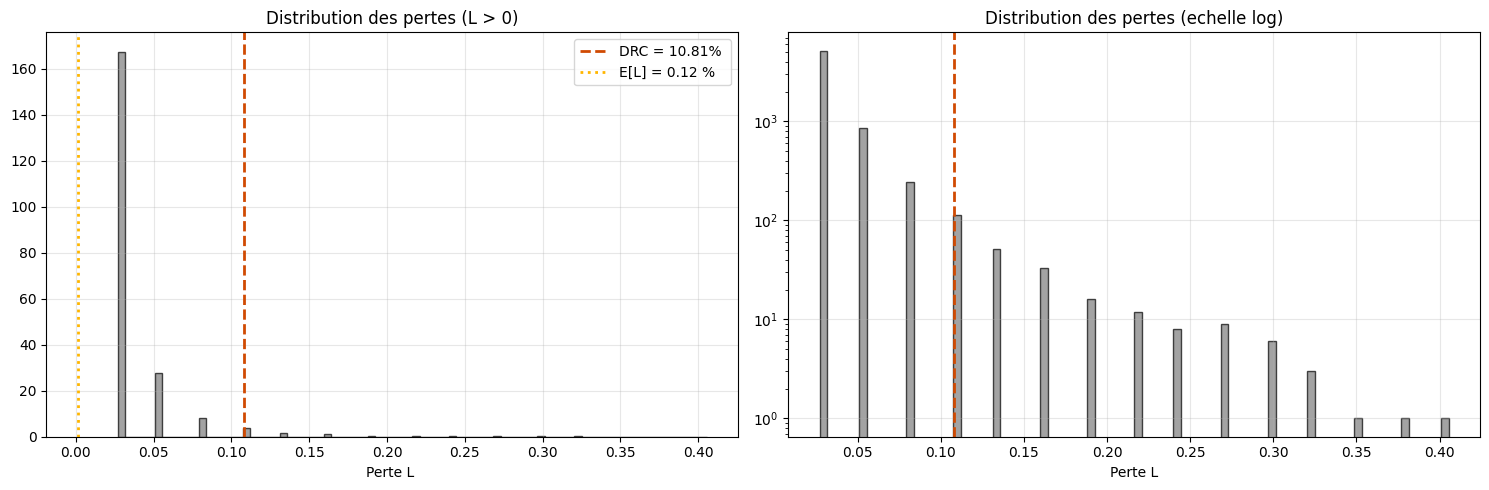


Statistiques :
  % scenarios sans defaut    : 96.73%
  % scenarios avec defaut    : 3.27%
  Skewness                   : 13.861
  Kurtosis                   : 323.747


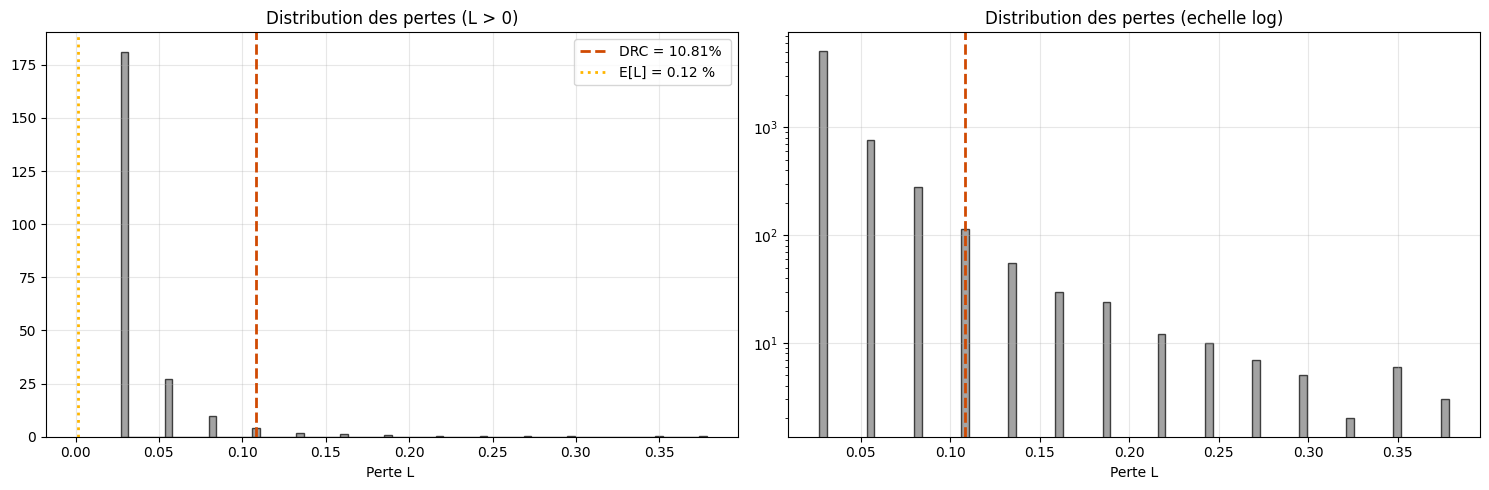


Statistiques :
  % scenarios sans defaut    : 96.77%
  % scenarios avec defaut    : 3.23%
  Skewness                   : 14.699
  Kurtosis                   : 360.389


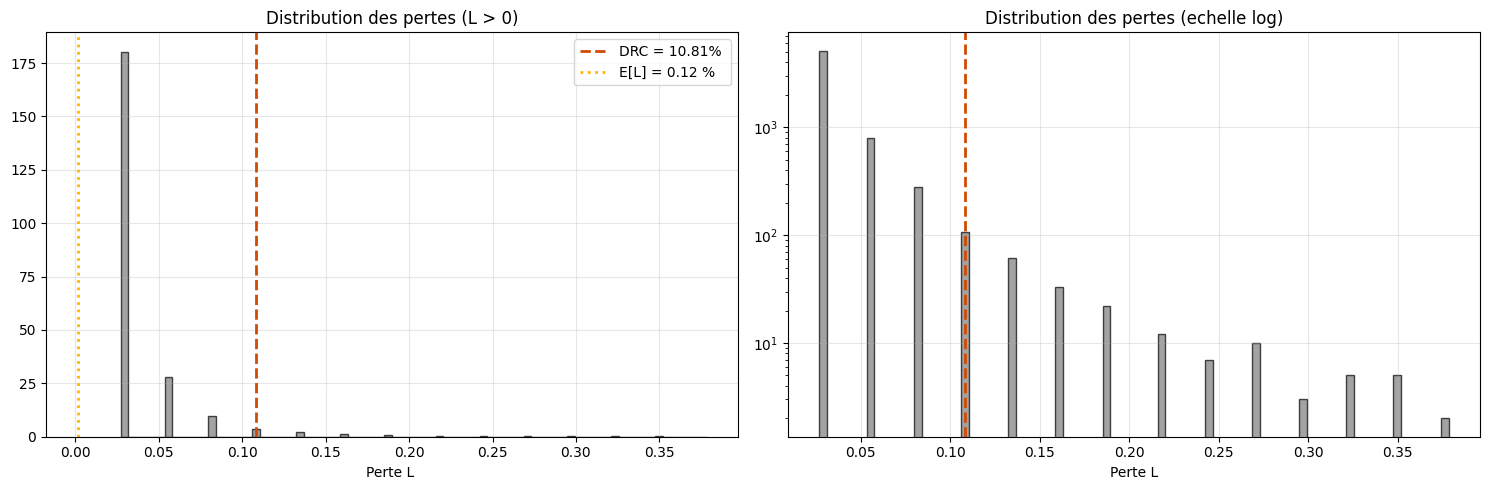


Statistiques :
  % scenarios sans defaut    : 96.76%
  % scenarios avec defaut    : 3.24%
  Skewness                   : 14.478
  Kurtosis                   : 348.352


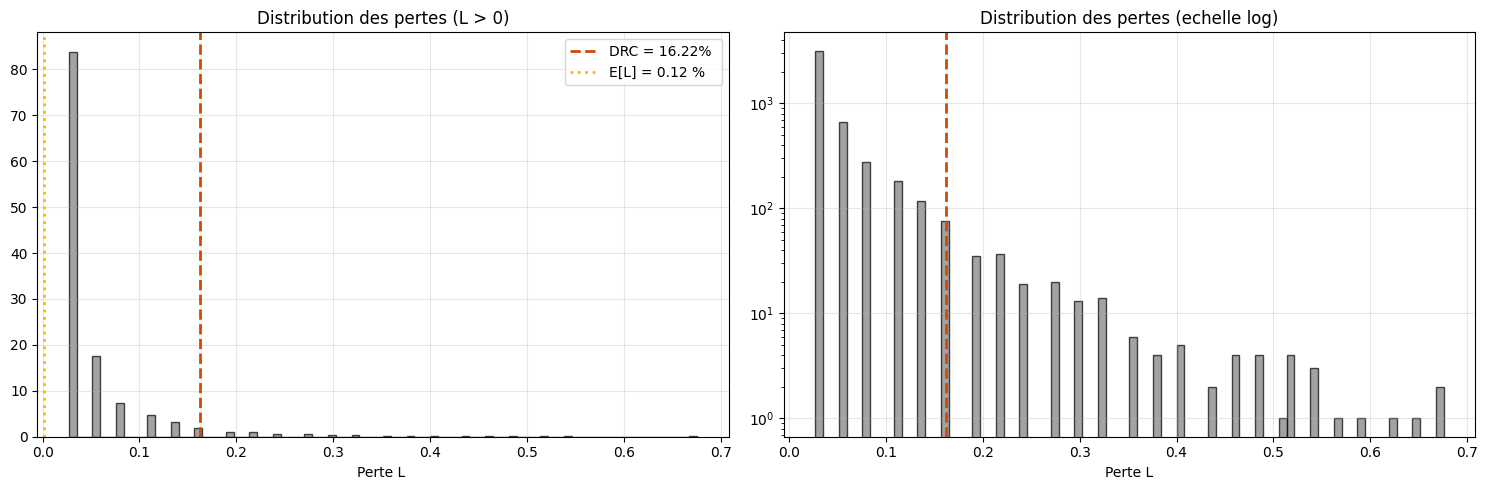


Statistiques :
  % scenarios sans defaut    : 97.67%
  % scenarios avec defaut    : 2.33%
  Skewness                   : 21.729
  Kurtosis                   : 705.569


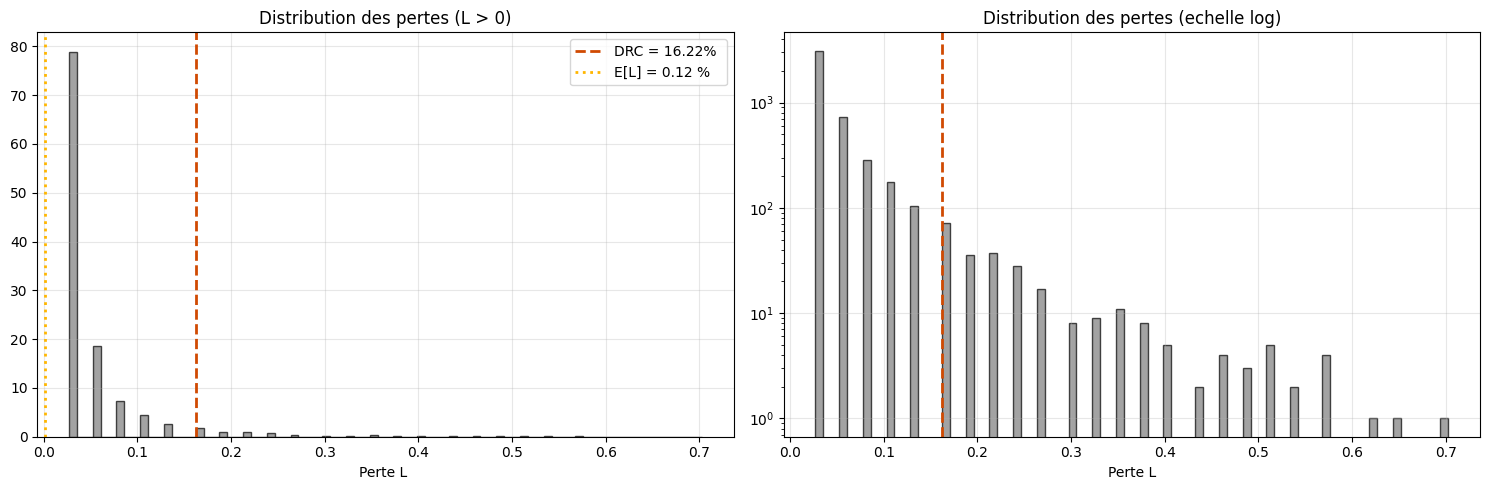


Statistiques :
  % scenarios sans defaut    : 97.67%
  % scenarios avec defaut    : 2.33%
  Skewness                   : 21.582
  Kurtosis                   : 691.359


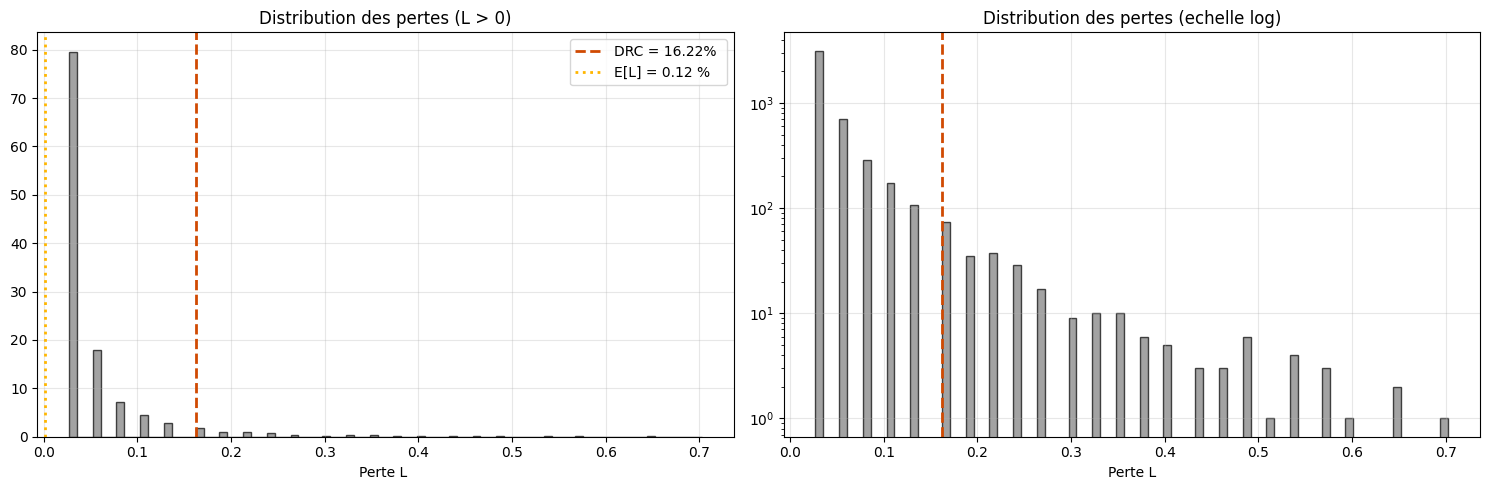


Statistiques :
  % scenarios sans defaut    : 97.67%
  % scenarios avec defaut    : 2.33%
  Skewness                   : 21.724
  Kurtosis                   : 702.316


,période,méthode,E[L],EL_erreur,DRC_sec,DRC_erreur
0,crise_2008,pca_iterative,0.001208,0.000049,0.135135,0.012979
1,crise_2008,frobenius,0.001206,0.000049,0.135135,0.012978
2,crise_2008,mle,0.001208,0.000048,0.135135,0.013610
3,calme_2010s,pca_iterative,0.001224,0.000037,0.108108,0.008703
4,calme_2010s,frobenius,0.001223,0.000038,0.108108,0.010053
5,calme_2010s,mle,0.001232,0.000038,0.108108,0.010461
6,covid,pca_iterative,0.001217,0.000053,0.162162,0.013612
7,covid,frobenius,0.001222,0.000053,0.162162,0.011608
8,covid,mle,0.001220,0.000053,0.162162,0.012976


In [20]:
M_SIMULATIONS = 200_000  # à ajuster selon le budget de calcul disponible

drc_records = []
for period in returns_by_period:
    for method in ["pca_iterative", "frobenius", "mle"]:
        model = comparator.get_model(period, method)
        common = [t for t in common_assets if t in model.tickers]

        drc_engine = DrcModel(
            model,
            prob_default[[common_assets.index(t) for t in common]],
            lgd[[common_assets.index(t) for t in common]],
            (jtd[common] / jtd[common].sum()).values,
            M=M_SIMULATIONS,
        )
        result = drc_engine.simulate(batch_size=10_000, label=f"{period}_{method}")

        drc_records.append({
            "période": period, "méthode": method,
            "E[L]": result.EL, "EL_erreur": result.EL_error,
            "DRC_sec": result.DRC_sec, "DRC_erreur": result.Error_sec,
        })

        plot_loss_distribution(result)

drc_table = pd.DataFrame(drc_records)
drc_table


### 3.3.4 Isolation de l'effet de `Sigma_Z`

Pour isoler l'effet propre du critère d'ajustement de `beta`, indépendamment du
traitement de `Sigma_Z`, on compare deux configurations sur chaque période :
1. `Sigma_Z` figé à l'identité pour les trois méthodes ;
2. `Sigma_Z` estimé conjointement avec `beta` pour l'EM seul.


In [21]:
drc_records_fixed = []
for period, returns in returns_by_period.items():
    for method in ["pca_iterative", "frobenius", "mle"]:
        model = PCAFactorModel(returns, n_factors=N_FACTORS)  # Sigma_Z = I_J
        model.fit()
        kwargs = {"max_iter": 300, "tol": 1e-8} if method == "em" else {}
        model.calibrate_beta(method, **kwargs)

        common = [t for t in common_assets if t in model.tickers]
        drc_engine = DrcModel(
            model,
            prob_default[[common_assets.index(t) for t in common]],
            lgd[[common_assets.index(t) for t in common]],
            (jtd[common] / jtd[common].sum()).values,
            M=M_SIMULATIONS,
        )
        result = drc_engine.simulate(batch_size=10_000, label=f"{period}_{method}_SigmaZ=I")
        drc_records_fixed.append({
            "période": period, "méthode": method, "Sigma_Z": "identité",
            "DRC_sec": result.DRC_sec, "DRC_erreur": result.Error_sec,
        })

drc_table_fixed = pd.DataFrame(drc_records_fixed)
drc_table_fixed


,période,méthode,Sigma_Z,DRC_sec,DRC_erreur
0,crise_2008,pca_iterative,identité,0.135135,0.012979
1,crise_2008,frobenius,identité,0.135135,0.012978
2,crise_2008,mle,identité,0.135135,0.013610
3,calme_2010s,pca_iterative,identité,0.108108,0.008703
4,calme_2010s,frobenius,identité,0.108108,0.010053
5,calme_2010s,mle,identité,0.108108,0.010461
6,covid,pca_iterative,identité,0.162162,0.013612
7,covid,frobenius,identité,0.162162,0.011608
8,covid,mle,identité,0.162162,0.012976


### 3.3.5 Comparaison au benchmark standardisé

Le benchmark standardisé (pondérations réglementaires forfaitaires, CRR3 Tableau 2)
est invariant par construction au choix de la période de calibration : il permet de
mesurer si la sensibilité des méthodes internes au choix de la période reste
économiquement significative au regard de l'écart, généralement plus large, entre
approche interne et approche standardisée.


In [22]:
ratings_subset = {t: ratings[t] for t in common_assets}
drc_std_engine = DrcStandard(strict=True)
std_result = drc_std_engine.compute(jtd=jtd.to_dict(), ratings=ratings_subset)
drc_std_engine.report(std_result)



RESULTATS DRC STANDARD CRR3 [Equity Long-Only]
Nombre d'obligors  : 37
JTD total          : 1.00
DRC Standard total : 0.04
DRC / JTD total    : 4.35%


## Dynamique du DRC sur fenêtres glissantes

Prolonge à une échelle plus fine la comparaison inter-périodes ci-dessus (chapitre 3,
section 3.3.4) : au lieu de trois points discrets, on observe la trajectoire complète
de la sensibilité de la méthode EM au choix de la fenêtre de calibration.


In [23]:
from DRC.code.moving_drc import (
    compute_annual_calibration_panel,
    plot_metric_across_methods,
    plot_all_metrics,
)


panel = compute_annual_calibration_panel(
    tickers=common_assets,           # univers candidat (sera réduit à l'univers commun fixe)
    prices=loader.prices,            # DataFrame de prix déjà chargé
    prob_default=prob_default,       # aligné sur common_assets
    lgd=lgd,                         # aligné sur common_assets
    factor_model_class=PCAFactorModel,
    drc_model_class=DrcModel,
    n_factors=N_FACTORS,             # ex. 2, commun aux 3 méthodes
    start="2008-01-01",
    end="2026-01-01",
    methods=["pca_iterative", "frobenius", "mle"],
    method_kwargs={"em": {"max_iter": 300, "tol": 1e-8}},
    max_missing_pct=0.05,            # seuil appliqué UNE FOIS sur toute la plage
    M=100_000,                       # simulations Monte Carlo par (période, méthode)
    batch_size=10_000,
    verbose=True,                    # affiche la progression période par période
)

panel  # table longue : 12 périodes x 3 méthodes = 36 lignes

[2008-01-01] pca_iterative  | n_assets= 37 | Frobenius=1.1915 | corr_moy(impl.)=0.534 | DRC=0.1351


[2008-01-01] frobenius      | n_assets= 37 | Frobenius=1.1915 | corr_moy(impl.)=0.534 | DRC=0.1351


[2008-01-01] mle            | n_assets= 37 | Frobenius=1.2301 | corr_moy(impl.)=0.533 | DRC=0.1351


[2009-01-01] pca_iterative  | n_assets= 37 | Frobenius=1.4581 | corr_moy(impl.)=0.408 | DRC=0.1081


[2009-01-01] frobenius      | n_assets= 37 | Frobenius=1.4581 | corr_moy(impl.)=0.408 | DRC=0.1081


...

[2024-01-01] mle            | n_assets= 37 | Frobenius=1.9446 | corr_moy(impl.)=0.238 | DRC=0.0811

[2025-01-01] pca_iterative  | n_assets= 37 | Frobenius=1.9080 | corr_moy(impl.)=0.267 | DRC=0.0811


[2025-01-01] frobenius      | n_assets= 37 | Frobenius=1.9080 | corr_moy(impl.)=0.267 | DRC=0.0811


[2025-01-01] mle            | n_assets= 37 | Frobenius=1.9319 | corr_moy(impl.)=0.265 | DRC=0.0811


,period_start,period_end,period_label,n_assets,method,frobenius_gap,rmse_gap,mean_corr_empirical,mean_corr_implied,DRC_sec,DRC_error,EL,EL_error,n_iter,converged
0,2008-01-01,2009-01-01,2008-01-01,37,pca_iterative,1.191458,0.032646,0.533712,0.533660,0.135135,0.017049,0.001207,0.000069,20.0,True
1,2008-01-01,2009-01-01,2008-01-01,37,frobenius,1.191458,0.032646,0.533712,0.533660,0.135135,0.015791,0.001184,0.000070,NaN,None
2,2008-01-01,2009-01-01,2008-01-01,37,mle,1.230071,0.033704,0.533712,0.533288,0.135135,0.015791,0.001186,0.000069,NaN,None
3,2009-01-01,2010-01-01,2009-01-01,37,pca_iterative,1.458091,0.039951,0.408049,0.407914,0.108108,0.011159,0.001195,0.000056,23.0,True
4,2009-01-01,2010-01-01,2009-01-01,37,frobenius,1.458091,0.039951,0.408049,0.407914,0.108108,0.011159,0.001204,0.000056,NaN,None
5,2009-01-01,2010-01-01,2009-01-01,37,mle,1.520811,0.041670,0.408049,0.406534,0.108108,0.011162,0.001193,0.000055,NaN,None
6,2010-01-01,2011-01-01,2010-01-01,37,pca_iterative,1.129504,0.030948,0.486005,0.486039,0.135135,0.018228,0.001201,0.000066,19.0,True
7,2010-01-01,2011-01-01,2010-01-01,37,frobenius,1.129504,0.030948,0.486005,0.486039,0.135135,0.012886,0.001208,0.000067,NaN,None
8,2010-01-01,2011-01-01,2010-01-01,37,mle,1.165771,0.031942,0.486005,0.485867,0.135135,0.014405,0.001208,0.000067,NaN,None
9,2011-01-01,2012-01-01,2011-01-01,37,pca_iterative,0.933449,0.025576,0.586169,0.586112,0.162162,0.014416,0.001198,0.000077,17.0,True


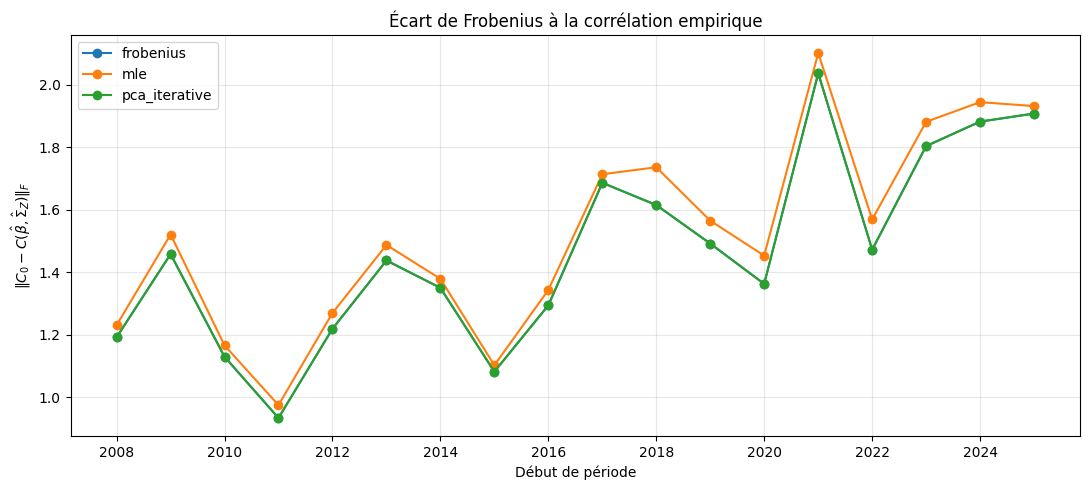

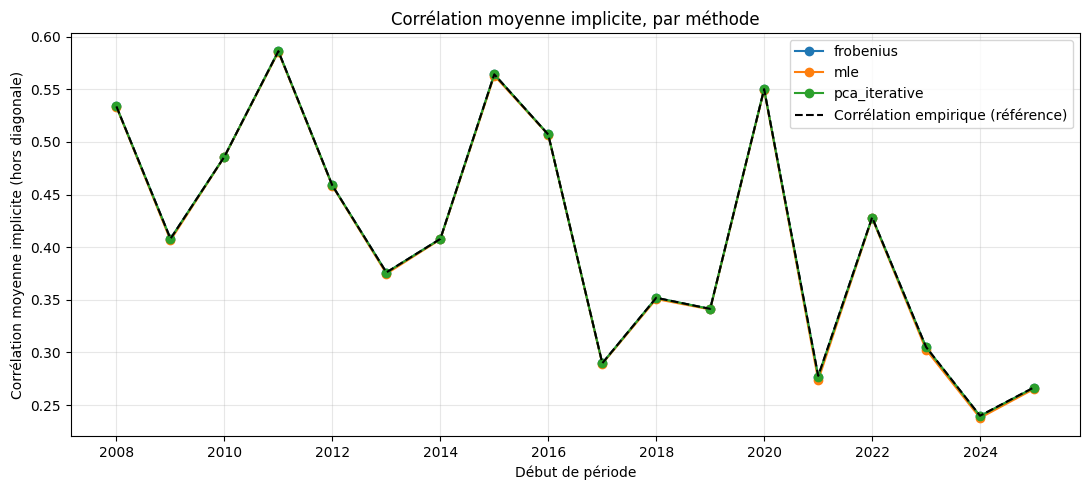

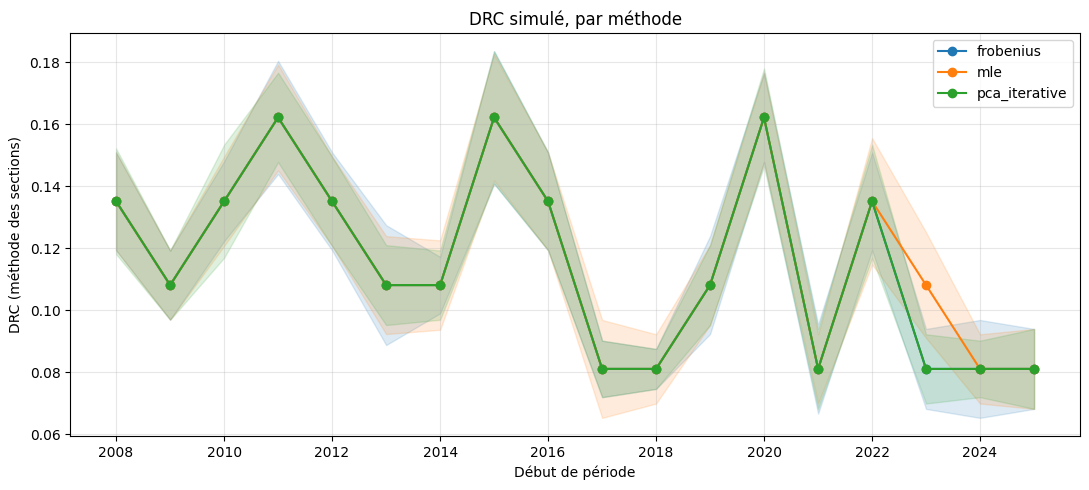

In [24]:
figures = plot_all_metrics(panel)

plt.show()

## 3.4 Discussion

Cf. chapitre 3, section 3.4 du mémoire : retour sur l'ambiguïté réglementaire à la
lumière des résultats obtenus ci-dessus, limites (cadre gaussien, hypothèse iid,
portée du dispositif), et prolongements.
